In [1]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [2]:
import random
import numpy as np
import torch
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.mps.deterministic = True

## training a VAE

In [3]:
import torch
import rdkit
from rdkit import Chem
print(torch.__version__)
print(Chem.MolFromSmiles("CCO"))

2.11.0


In [4]:
from tdc.single_pred import ADME

data = ADME(name='CYP2D6_Veith')
split = data.get_split()
train_df = split['train']
valid_df = split['valid']
test_df  = split['test']

print(f"Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")
train_df.head()

Found local copy...
Loading...
Done!


Train: 9191, Valid: 1313, Test: 2626


,Drug_ID,Drug,Y
0,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,0
1,644890.0,COc1ccccc1C(c1nnnn1C(C)(C)C)N1CCN(Cc2ccncc2)CC1,1
2,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0
3,6602688.0,Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c...,1
4,645448.0,CCC(C)(C)NC(=O)c1ccc2c(c1)N(CC(=O)OC)C(=O)C(C)...,0


In [5]:
full_df = pd.concat([train_df, valid_df, test_df])
print(full_df['Y'].value_counts())
print(full_df['Y'].value_counts(normalize=True))

Y
0    10616
1     2514
Name: count, dtype: int64
Y
0    0.80853
1    0.19147
Name: proportion, dtype: float64


## building the character vocabulary
we start off by building the character vocabulary, since a VAE encodes smiles strings into a latent vector. a neural network cant take raw text - only numbers, so we convert each character in a smiles string to an integer.

`<pad>` - used to make all SMILES the same length in a batch (token = 0)

`<sos>` - start of sequence, tells the decoder to begin generating (token = 1)

`<eos>` - end of sequence, tells the decoder to stop (token = 2)

!!!! this can raise an issue because neural networks care abt what the numbers mean - check the thing with 0 and 1s (one hot encodding)

In [6]:
train_smiles = train_df['Drug'].tolist()
valid_smiles = valid_df['Drug'].tolist()
test_smiles  = test_df['Drug'].tolist()
df = pd.concat([train_df, valid_df, test_df])
all_smiles = df['Drug'].tolist()
vocab = sorted(set(''.join(all_smiles)))
vocab = ['<pad>', '<sos>', '<eos>'] + vocab

char2idx = {ch: idx for idx, ch in enumerate(vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

print(f"Vocabulary size: {len(vocab)}")
print(f"Characters: {vocab}")

Vocabulary size: 55
Characters: ['<pad>', '<sos>', '<eos>', '#', '%', '(', ')', '+', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'W', 'Z', '[', '\\', ']', 'a', 'b', 'c', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's', 't', 'u']


Next step is to check the distribution of SMILES lengths to configure padding

Max length: 340
Mean length: 46.0
95th percentile: 83


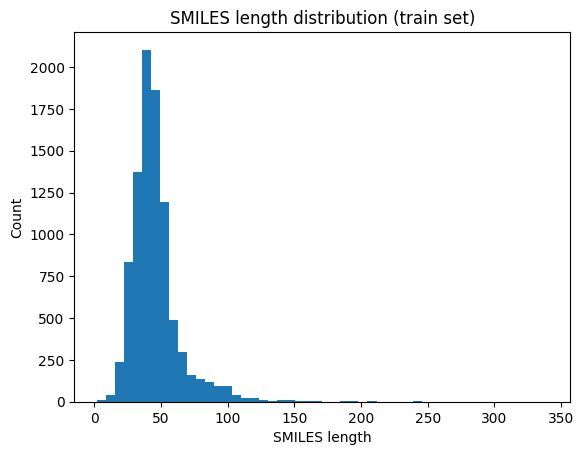

In [7]:
import matplotlib.pyplot as plt

lengths = [len(s) for s in train_smiles]
print(f"Max length: {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.1f}")
print(f"95th percentile: {sorted(lengths)[int(0.95*len(lengths))]}")

plt.hist(lengths, bins=50)
plt.xlabel("SMILES length")
plt.ylabel("Count")
plt.title("SMILES length distribution (train set)")
plt.show()

the distribution is right-skewed, with a mean length of smiles strings being 46.1 (small molecules) and the 95th percentile is 85, so we set `max_length` = 100

## Tokenization and Encoding of SMILES 

In [8]:
import torch

MAX_LENGTH = 100

def encode_smiles(smiles, char2idx, max_length):
    """
    Convert a SMILES string to a fixed-length integer sequence.
    
    Wraps the sequence with <sos> and <eos> tokens, truncates sequences
    longer than max_length, and pads shorter sequences with <pad> tokens.
    
    Args:
        smiles (str): SMILES string of a molecule.
        char2idx (dict): mapping from character to integer index.
        max_length (int): fixed length for all output sequences.
    
    Returns:
        list[int]: integer-encoded sequence of length max_length.
    """
    tokens = ['<sos>'] + list(smiles) + ['<eos>']
    tokens = tokens[:max_length]
    tokens += ['<pad>'] * (max_length - len(tokens))
    return [char2idx[t] for t in tokens]


In [9]:
smiles_list = train_smiles[:5]
example = smiles_list[0]
encoded = encode_smiles(example, char2idx, MAX_LENGTH)
print(f"SMILES: {example}")
print(f"Encoded: {encoded}")
print(f"Length: {len(encoded)}")

SMILES: CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1
Encoded: [1, 25, 25, 5, 21, 33, 6, 32, 5, 44, 12, 44, 44, 44, 13, 50, 44, 5, 21, 33, 6, 52, 44, 13, 44, 12, 6, 36, 5, 21, 33, 6, 5, 21, 33, 6, 44, 12, 44, 44, 44, 52, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 100


In [10]:
encoded_train = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in train_smiles], dtype=torch.long)
encoded_valid = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in valid_smiles], dtype=torch.long)
encoded_test  = torch.tensor([encode_smiles(s, char2idx, MAX_LENGTH) for s in test_smiles],  dtype=torch.long)

train_labels = torch.tensor(train_df['Y'].tolist(), dtype=torch.float)
valid_labels = torch.tensor(valid_df['Y'].tolist(), dtype=torch.float)
test_labels  = torch.tensor(test_df['Y'].tolist(),  dtype=torch.float)

print(f"encoded_train: {encoded_train.shape}  pos rate: {train_labels.mean():.3f}")
print(f"encoded_valid: {encoded_valid.shape}  pos rate: {valid_labels.mean():.3f}")
print(f"encoded_test:  {encoded_test.shape}   pos rate: {test_labels.mean():.3f}")

encoded_train: torch.Size([9191, 100])  pos rate: 0.192
encoded_valid: torch.Size([1313, 100])  pos rate: 0.198
encoded_test:  torch.Size([2626, 100])   pos rate: 0.186


## build the pytorch dataset and dataloader

In [11]:
from torch.utils.data import Dataset, DataLoader

class SMILESDataset(Dataset):
    def __init__(self, encoded_data, labels):
        self.data = encoded_data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

train_dataset = SMILESDataset(encoded_train, train_labels)
valid_dataset = SMILESDataset(encoded_valid, valid_labels)
test_dataset  = SMILESDataset(encoded_test,  test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Valid: {len(valid_dataset)} samples, {len(valid_loader)} batches")
print(f"Test:  {len(test_dataset)} samples, {len(test_loader)} batches")

Train: 9191 samples, 144 batches
Valid: 1313 samples, 21 batches
Test:  2626 samples, 42 batches


## VAE Model

The VAE consists of three components:
- **Encoder** (MLP): flattens the one-hot SMILES sequence and compresses it to a latent distribution via two linear layers
- **Reparameterisation**: samples from the latent distribution while keeping the computation graph differentiable
- **Decoder** (GRU): reconstructs the SMILES sequence autoregressively from the latent vector

In [12]:
import torch.nn as nn
import torch.nn.functional as F


class Encoder(nn.Module):
    """
    Encodes a tokenised SMILES sequence into a latent distribution (mu, log_var)
    using two 1D convolutional layers followed by a fully-connected projection.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed length of the input sequence (MAX_LENGTH).
        hidden_dim (int): width of the fully-connected layer after flattening.
        latent_dim (int): dimension of the latent space.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.conv = nn.Sequential(
            nn.Conv1d(vocab_size, 128, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.Tanh(),
        )
        self.fc = nn.Linear(256 * seq_len, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch of shape (batch_size, seq_len).

        Returns:
            mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
        """
        embedded = F.one_hot(x, num_classes=self.vocab_size).float()  # (batch, seq_len, vocab_size)
        x_conv = embedded.permute(0, 2, 1)                            # (batch, vocab_size, seq_len)
        h = self.conv(x_conv)                                         # (batch, 256, seq_len)
        h = h.view(h.size(0), -1)                                     # (batch, 256 * seq_len)
        h = F.relu(self.fc(h))                                        # (batch, hidden_dim)
        return self.fc_mu(h), self.fc_logvar(h)

### Reparameterisation

The encoder outputs `mu` and `log_var`, which define a probability distribution in latent space.
We sample a latent vector `z` from this distribution using the reparameterisation trick.
This allows gradients to flow through the sampling step during backpropagation.

trick to make it differntiable

In [13]:
def reparameterise(mu, log_var):
    """
    Sample a latent vector z using the reparameterisation trick.
    
    Instead of sampling z directly from N(mu, std), we sample epsilon from N(0,1)
    and compute z = mu + epsilon * std. This keeps the sampling step differentiable.
    
    Args:
        mu (Tensor): mean of the latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of the latent distribution, shape (batch_size, latent_dim).
    
    Returns:
        z (Tensor): sampled latent vector, shape (batch_size, latent_dim).
    """
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

### Decoder

The decoder takes the latent vector z and reconstructs the SMILES sequence token by token.
It uses a GRU that generates one token at a time, conditioned on z.

In [14]:
class Decoder(nn.Module):
    """
    Decodes a latent vector z into a SMILES sequence autoregressively.
    
    z is repeated across all timesteps via RepeatVector and concatenated
    with the one-hot token input at each step, so the GRU sees z at every
    timestep rather than only at initialisation. Hard teacher forcing is used
    during training.
    
    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        hidden_dim (int): hidden dimension of the GRU.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers.
    """
    def __init__(self, vocab_size, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.vocab_size = vocab_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim
        self.fc_z = nn.Linear(latent_dim, hidden_dim * n_layers)
        self.gru = nn.GRU(vocab_size + latent_dim, hidden_dim, n_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, z, x):
        """
        Args:
            z (Tensor): latent vector, shape (batch_size, latent_dim).
            x (Tensor): target sequence, shape (batch_size, seq_len).
        
        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
        """
        hidden = self.fc_z(z)
        hidden = hidden.view(-1, self.n_layers, self.hidden_dim).permute(1, 0, 2).contiguous()

        seq_len = x.size(1) - 1
        x_onehot = F.one_hot(x[:, :-1], num_classes=self.vocab_size).float()  # (batch, seq_len-1, vocab_size)
        z_repeated = z.unsqueeze(1).expand(-1, seq_len, -1)                   # (batch, seq_len-1, latent_dim)
        gru_input = torch.cat([x_onehot, z_repeated], dim=-1)                 # (batch, seq_len-1, vocab_size + latent_dim)

        output, _ = self.gru(gru_input, hidden)
        logits = self.fc_out(output)
        return logits

In [15]:
class PropertyPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_size=64, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, mu):
        return self.net(mu).squeeze(-1)


class VAE(nn.Module):
    """
    Variational Autoencoder for SMILES strings.

    Combines the Encoder (MLP), reparameterisation trick, and Decoder (GRU) into
    a single model. The encoder compresses a flattened SMILES one-hot sequence into
    a latent distribution; a latent vector z is sampled via reparameterisation; the
    decoder reconstructs the sequence autoregressively from z.

    Args:
        vocab_size (int): number of unique tokens in the vocabulary.
        seq_len (int): fixed input sequence length passed to the MLP encoder.
        hidden_dim (int): hidden dimension for both encoder and decoder.
        latent_dim (int): dimension of the latent space.
        n_layers (int): number of GRU layers in the decoder.
    """
    def __init__(self, vocab_size, seq_len, hidden_dim, latent_dim, n_layers):
        super().__init__()
        self.encoder = Encoder(vocab_size, seq_len, hidden_dim, latent_dim)
        self.decoder = Decoder(vocab_size, hidden_dim, latent_dim, n_layers)
        self.predictor = PropertyPredictor(latent_dim)

    def forward(self, x):
        """
        Args:
            x (Tensor): tokenised SMILES batch, shape (batch_size, seq_len).

        Returns:
            logits (Tensor): predicted token scores, shape (batch_size, seq_len-1, vocab_size).
            mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
            log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
            prop_logit (Tensor): property prediction logit, shape (batch_size,).
        """
        mu, log_var = self.encoder(x)
        z = reparameterise(mu, log_var)
        logits = self.decoder(z, x)
        prop_logit = self.predictor(mu)
        return logits, mu, log_var, prop_logit

In [16]:
VOCAB_SIZE = len(vocab)
HIDDEN_DIM = 512
LATENT_DIM = 128
N_LAYERS = 2

model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(55, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): Tanh()
      (2): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (3): Tanh()
    )
    (fc): Linear(in_features=25600, out_features=512, bias=True)
    (fc_mu): Linear(in_features=512, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc_z): Linear(in_features=128, out_features=1024, bias=True)
    (gru): GRU(183, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=55, bias=True)
  )
  (predictor): PropertyPredictor(
    (net): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Total parameters: 16,174,008


In [17]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: mps


## Loss Function

The VAE loss has two components:
- Reconstruction loss: how well the decoder reconstructs the input SMILES
- KL divergence: how close the latent distribution is to a standard normal N(0,1)

Total loss = reconstruction loss + beta * KL divergence

In [18]:
def vae_loss(logits, targets, mu, log_var, beta, prop_logit=None, labels=None, gamma=0.0):
    """
    Compute the VAE loss: reconstruction loss + beta * KL divergence + gamma * property loss.

    Args:
        logits (Tensor): predicted token scores, shape (batch_size, seq_len, vocab_size).
        targets (Tensor): true token indices, shape (batch_size, seq_len).
        mu (Tensor): mean of latent distribution, shape (batch_size, latent_dim).
        log_var (Tensor): log variance of latent distribution, shape (batch_size, latent_dim).
        beta (float): weight on the KL term.
        prop_logit (Tensor, optional): property prediction logits, shape (batch_size,).
        labels (Tensor, optional): binary property labels, shape (batch_size,).
        gamma (float): weight on the property prediction loss.

    Returns:
        loss (Tensor): total VAE loss.
        recon_loss (Tensor): reconstruction loss component.
        kl_loss (Tensor): KL divergence component.
        prop_loss (Tensor): property prediction loss component (zero if not used).
    """
    recon_loss = nn.CrossEntropyLoss(ignore_index=0)(
        logits.view(-1, logits.size(-1)),
        targets.reshape(-1)
    )

    kl_free_bits = 1.0
    kl_loss = torch.clamp(-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()), min=kl_free_bits)

    prop_loss = torch.tensor(0.0, device=logits.device)
    if prop_logit is not None and labels is not None and gamma > 0:
        pos_weight = torch.tensor(4.22, device=logits.device)
        prop_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(prop_logit, labels)

    loss = recon_loss + beta * kl_loss + gamma * prop_loss
    return loss, recon_loss, kl_loss, prop_loss

## Training Loop

We train the VAE for 50 epochs. Three stabilisation techniques are combined:

- **KL annealing**: beta ramps from 0 → 1 over the first 20 epochs, then stays at 1 for the remaining 30 epochs. Separating ANNEAL_EPOCHS from EPOCHS ensures the model trains for a sustained period under full regularisation — previously both were 30, so beta never actually reached 1.0 within the run.
- **Scheduled sampling**: epsilon decays 1.0 → 0.1, gradually weaning the decoder off teacher forcing.
- **ReduceLROnPlateau**: halves the learning rate when total loss plateaus, preventing oscillation late in training.

In [19]:
def evaluate(model, dataset, vocab_size, device, idx2char, n_samples=500):
    """
    Measure reconstruction accuracy and validity on a random subset of the dataset.

    Encodes n_samples real molecules to mu (no noise), decodes with teacher forcing
    and hard argmax, then reports exact sequence match rate and RDKit validity rate.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(batch)
        logits = model.decoder(mu, batch)       # (n_samples, seq_len-1, vocab_size)
        pred_tokens = logits.argmax(dim=-1)     # (n_samples, seq_len-1)

    targets = batch[:, 1:]                      # (n_samples, seq_len-1)
    exact_acc = (pred_tokens == targets).all(dim=1).float().mean().item()

    valid_count = 0
    for seq in pred_tokens:
        chars = [idx2char[idx.item()] for idx in seq]
        smiles = ''
        for ch in chars:
            if ch == '<eos>':
                break
            if ch not in ['<pad>', '<sos>']:
                smiles += ch
        if smiles and Chem.MolFromSmiles(smiles) is not None:
            valid_count += 1
    validity = valid_count / n_samples

    return exact_acc, validity

## MLflow Experiment Tracking

Each training run is logged to a local MLflow experiment called `mol-vae`.  
Run `mlflow ui` in the terminal to open the tracking UI at http://localhost:5000

In [20]:
import mlflow
import torch.optim as optim
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import roc_auc_score

EPOCHS = 50
BETA_MAX = 1.0
ANNEAL_EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
KL_FREE_BITS = 1.0
GAMMA = 0.1

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri("file:///Users/elenipsaromatis/Documents/mol-vae/notebooks/mlruns")
mlflow.set_experiment("mol-vae")

with mlflow.start_run() as run:
    run_id = run.info.run_id
    mlflow.set_tag("mlflow.runName", f"vae_{run_id[:8]}")
    model_path = CHECKPOINT_DIR / f"vae_{run_id[:8]}.pth"
    writer = SummaryWriter(log_dir=f"../runs/{run_id[:8]}")

    mlflow.log_params({
        "vocab_size": VOCAB_SIZE,
        "max_length": MAX_LENGTH,
        "hidden_dim": HIDDEN_DIM,
        "latent_dim": LATENT_DIM,
        "n_layers": N_LAYERS,
        "epochs": EPOCHS,
        "anneal_epochs": ANNEAL_EPOCHS,
        "beta_max": BETA_MAX,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "kl_free_bits": KL_FREE_BITS,
        "gamma": GAMMA,
        "pos_weight": 4.22,
    })

    model = VAE(VOCAB_SIZE, MAX_LENGTH, HIDDEN_DIM, LATENT_DIM, N_LAYERS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    def evaluate_loss(model, loader, beta, gamma):
        model.eval()
        total_recon, total_kl, total_prop, n = 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for batch, labels in loader:
                batch  = batch.to(device)
                labels = labels.to(device)
                logits, mu, log_var, prop_logit = model(batch)
                _, recon, kl, prop = vae_loss(logits, batch[:, 1:], mu, log_var, beta,
                                              prop_logit=prop_logit, labels=labels, gamma=gamma)
                total_recon += recon.item()
                total_kl    += kl.item()
                total_prop  += prop.item()
                n += 1
        return total_recon / n, total_kl / n, total_prop / n

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        total_recon = 0
        total_kl = 0
        total_prop = 0
        total_grad_norm = 0

        beta = min(BETA_MAX, BETA_MAX * epoch / ANNEAL_EPOCHS)

        for batch, labels in train_loader:
            batch  = batch.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            logits, mu, log_var, prop_logit = model(batch)
            loss, recon_loss, kl_loss, prop_loss = vae_loss(
                logits, batch[:, 1:], mu, log_var, beta,
                prop_logit=prop_logit, labels=labels, gamma=GAMMA
            )

            loss.backward()

            grad_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    grad_norm += p.grad.data.norm(2).item() ** 2
            total_grad_norm += grad_norm ** 0.5

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()
            total_prop  += prop_loss.item()

        n_batches = len(train_loader)
        avg_loss   = total_loss  / n_batches
        train_prop = total_prop  / n_batches
        scheduler.step(avg_loss)

        valid_recon, valid_kl, valid_prop = evaluate_loss(model, valid_loader, beta, GAMMA)
        exact_acc, validity = evaluate(model, train_dataset, VOCAB_SIZE, device, idx2char)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:>2}/{EPOCHS}, beta: {beta:.2f} , "
              f"Loss: {avg_loss:.4f}  Recon: {total_recon/n_batches:.4f}  "
              f"KL: {total_kl/n_batches:.4f}  Prop: {train_prop:.4f}  "
              f"Grad: {total_grad_norm/n_batches:.4f}  LR: {current_lr:.1e}")
        print(f"         Recon acc: {exact_acc:.3f}  Validity: {validity:.3f}  "
              f"Valid recon: {valid_recon:.4f}  Valid KL: {valid_kl:.4f}  Valid prop: {valid_prop:.4f}")

        metrics = {
            "train_loss":   avg_loss,
            "recon_loss":   total_recon / n_batches,
            "kl_loss":      total_kl / n_batches,
            "train_prop":   train_prop,
            "valid_recon":  valid_recon,
            "valid_kl":     valid_kl,
            "valid_prop":   valid_prop,
            "grad_norm":    total_grad_norm / n_batches,
            "beta":         beta,
            "learning_rate": current_lr,
            "recon_acc":    exact_acc,
            "validity":     validity,
        }
        mlflow.log_metrics(metrics, step=epoch + 1)
        for name, value in metrics.items():
            writer.add_scalar(name, value, epoch + 1)

    # test set evaluation
    def evaluate_test(model, loader, vocab_size, idx2char, device):
        model.eval()
        all_logits, all_targets, all_prop_logits, all_labels = [], [], [], []
        with torch.no_grad():
            for batch, labels in loader:
                batch  = batch.to(device)
                labels = labels.to(device)
                mu, _ = model.encoder(batch)
                logits = model.decoder(mu, batch)
                prop_logit = model.predictor(mu)
                all_logits.append(logits)
                all_targets.append(batch[:, 1:])
                all_prop_logits.append(prop_logit.cpu())
                all_labels.append(labels.cpu())

        all_logits  = torch.cat(all_logits,  dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        pred_tokens = all_logits.argmax(dim=-1)
        test_recon_acc = (pred_tokens == all_targets).all(dim=1).float().mean().item()

        valid_count = 0
        for seq in pred_tokens:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            if smiles and Chem.MolFromSmiles(smiles) is not None:
                valid_count += 1
        test_validity = valid_count / len(pred_tokens)

        all_prop_logits = torch.cat(all_prop_logits).numpy()
        all_labels      = torch.cat(all_labels).numpy()
        test_auroc = roc_auc_score(all_labels, all_prop_logits)

        return test_recon_acc, test_validity, test_auroc

    test_recon_acc, test_validity, test_auroc = evaluate_test(model, test_loader, VOCAB_SIZE, idx2char, device)
    print(f"\nTest — Recon acc: {test_recon_acc:.3f}  Validity: {test_validity:.3f}  AUROC: {test_auroc:.3f}")
    mlflow.log_metrics({
        "test_recon_acc": test_recon_acc,
        "test_validity":  test_validity,
        "test_auroc":     test_auroc,
    })

    torch.save(model.state_dict(), model_path)
    mlflow.set_tag("checkpoint", str(model_path.resolve()))
    writer.close()
    print(f"\nRun complete. Model saved as {model_path}")
    print(f"Run ID: {run_id}")

Epoch  1/50, beta: 0.00 , Loss: 2.3186  Recon: 2.2078  KL: 7.0688  Prop: 1.1071  Grad: 2.0349  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.000  Valid recon: 1.5983  Valid KL: 5.7168  Valid prop: 1.0458
Epoch  2/50, beta: 0.05 , Loss: 1.3136  Recon: 1.1582  KL: 1.1779  Prop: 0.9651  Grad: 1.4140  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.006  Valid recon: 0.8863  Valid KL: 1.0764  Valid prop: 0.9353
Epoch  3/50, beta: 0.10 , Loss: 0.9688  Recon: 0.7816  KL: 1.0218  Prop: 0.8500  Grad: 1.1634  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.020  Valid recon: 0.6863  Valid KL: 1.0023  Valid prop: 0.8920
Epoch  4/50, beta: 0.15 , Loss: 0.8435  Recon: 0.6183  KL: 1.0116  Prop: 0.7350  Grad: 1.1954  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.040  Valid recon: 0.5870  Valid KL: 1.0240  Valid prop: 0.9080
Epoch  5/50, beta: 0.20 , Loss: 0.7863  Recon: 0.5234  KL: 1.0125  Prop: 0.6039  Grad: 1.2293  LR: 1.0e-03
         Recon acc: 0.000  Validity: 0.050  Valid recon: 

In [21]:
torch.save(model.state_dict(), 'vae_trained13.pth')
print("Model saved")

Model saved


## Sampling evaluation

In [22]:
from rdkit import Chem

def sample_molecules(model, num_samples, latent_dim, device, idx2char, max_length=100):
    """
    Sample molecules from the VAE using ancestral sampling.

    At each decoding step we draw the next token from the model's exact
    conditional distribution p(x_t | x_{1:t-1}, z) via multinomial sampling.
    z is concatenated to the one-hot input at every step to match the decoder
    architecture.
    """
    model.eval()
    sos_idx = next(idx for idx, ch in idx2char.items() if ch == '<sos>')

    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)

        hidden = model.decoder.fc_z(z)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        input_token = torch.full((num_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(max_length):
            input_onehot = F.one_hot(input_token, num_classes=len(idx2char)).float()  # (batch, 1, vocab_size)
            z_step = z.unsqueeze(1)                                                    # (batch, 1, latent_dim)
            gru_input = torch.cat([input_onehot, z_step], dim=-1)                     # (batch, 1, vocab_size + latent_dim)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))                          # (batch, vocab_size)

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)                      # (batch, 1)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)  # (batch, max_length)

        valid_smiles = []
        for seq in generated:
            chars = [idx2char[idx.item()] for idx in seq]
            smiles = ''
            for ch in chars:
                if ch == '<eos>':
                    break
                if ch not in ['<pad>', '<sos>']:
                    smiles += ch
            valid_smiles.append(smiles)

    valid = [s for s in valid_smiles if Chem.MolFromSmiles(s) is not None]
    print(f"Sampled: {num_samples}")
    print(f"Valid SMILES: {len(valid)}")
    print(f"Validity rate: {len(valid)/num_samples*100:.1f}%")
    print("\nExamples:")
    for s in valid[:5]:
        print(s)

    return valid

valid_mols = sample_molecules(model, 100, LATENT_DIM, device, idx2char)

Sampled: 100
Valid SMILES: 13
Validity rate: 13.0%

Examples:
CCc1ccc(Cc2cn([N+](=O)c3ccccc3)CC2=O)cc1OC

CO[N+](Cc1ccco1)CC1(CCN(C)c2ccncc2)CC1
C=C(C)N1CC[C@H]2CC[N@+](c2ccc(F)cc2)N[C@@H]12
Oc1ccc(COc2cccnc2CN(Cc2ccccc2)CC1)c1cccc(Cl)c1


In [23]:
for s in valid_mols[:10]:
    print(s)

CCc1ccc(Cc2cn([N+](=O)c3ccccc3)CC2=O)cc1OC

CO[N+](Cc1ccco1)CC1(CCN(C)c2ccncc2)CC1
C=C(C)N1CC[C@H]2CC[N@+](c2ccc(F)cc2)N[C@@H]12
Oc1ccc(COc2cccnc2CN(Cc2ccccc2)CC1)c1cccc(Cl)c1
C(=O)N[C@@H](Cc1ccc(C)cc1)S(=O)(=O)c1cccc2cc(C)ccc12
C=C(N)[C@H](CNCCc1ccc(Cl)cc1)C(=O)O
Cn1c(C)c2c(c1C#N)c1c(C)[nH]c(=O)n2CCOC1=O
CC(=O)NCc1cn(Cc2ccc3c(c2)OCC3)c(C)c1
CCc1cc(C)c2c(=O)c(C)nc(Oc3ccc(Cl)cc3)c2nc1C


In [24]:
def evaluate_sampling_vs_reconstruction(model, dataset, idx2char, device, n_samples=500):
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        mu, _ = model.encoder(batch)
        
        # teacher forcing (reconstruction)
        logits_tf = model.decoder(mu, batch)
        pred_tf = logits_tf.argmax(dim=-1)
        targets = batch[:, 1:]
        recon_acc = (pred_tf == targets).all(dim=1).float().mean().item()
        
        # greedy autoregressive (no teacher forcing)
        sos_idx = next(idx for idx, ch in idx2char.items() if ch == '<sos>')
        eos_idx = next(idx for idx, ch in idx2char.items() if ch == '<eos>')
        
        hidden = model.decoder.fc_z(mu)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()
        input_token = torch.full((n_samples, 1), sos_idx, dtype=torch.long).to(device)
        
        generated = []
        for _ in range(batch.size(1) - 1):
            x_onehot = F.one_hot(input_token, num_classes=len(idx2char)).float()
            z_step = mu.unsqueeze(1)
            gru_input = torch.cat([x_onehot, z_step], dim=-1)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated.append(next_token)
            input_token = next_token
        
        generated = torch.cat(generated, dim=1)

    def decode_to_smiles(seq):
        chars = [idx2char[idx.item()] for idx in seq]
        smiles = ''
        for ch in chars:
            if ch == '<eos>':
                break
            if ch not in ['<pad>', '<sos>']:
                smiles += ch
        return smiles

    valid_tf, valid_ar = 0, 0
    for i in range(n_samples):
        if Chem.MolFromSmiles(decode_to_smiles(pred_tf[i])) is not None:
            valid_tf += 1
        if Chem.MolFromSmiles(decode_to_smiles(generated[i])) is not None:
            valid_ar += 1

    print(f"Reconstruction accuracy (teacher forcing): {recon_acc:.3f}")
    print(f"Validity under teacher forcing:            {valid_tf/n_samples:.3f}")
    print(f"Validity under autoregressive decoding:    {valid_ar/n_samples:.3f}")
    print(f"Exposure bias gap:                         {valid_tf/n_samples - valid_ar/n_samples:.3f}")

evaluate_sampling_vs_reconstruction(model, train_dataset, idx2char, device)

Reconstruction accuracy (teacher forcing): 0.028
Validity under teacher forcing:            0.976
Validity under autoregressive decoding:    0.978
Exposure bias gap:                         -0.002


In [25]:
def diagnose_latent_space(model, dataset, device, n_samples=500):
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        mu, log_var = model.encoder(batch)
    
    print(f"mu mean:    {mu.mean().item():.3f}")
    print(f"mu std:     {mu.std().item():.3f}")
    print(f"sigma mean: {log_var.exp().sqrt().mean().item():.3f}")
    
    # KL per dimension
    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp()).mean(0)
    print(f"KL per dim mean: {kl_per_dim.mean().item():.3f}")
    print(f"KL per dim max:  {kl_per_dim.max().item():.3f}")
    print(f"KL per dim min:  {kl_per_dim.min().item():.3f}")

diagnose_latent_space(model, train_dataset, device)

mu mean:    0.023
mu std:     0.863
sigma mean: 0.453
KL per dim mean: 0.965
KL per dim max:  3.259
KL per dim min:  0.136


## Encode → Decode Inspection

Encode a SMILES string through the VAE and compare the original to the reconstruction.

In [26]:
def inspect_dataset_reconstructions(model, dataset, smiles_list, char2idx, idx2char, device, n_samples=100):
    """
    Encode n_samples molecules from the dataset, decode them, and print
    the original vs reconstruction side by side with a character-level diff.
    """
    model.eval()
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        mu, log_var = model.encoder(batch)

        hidden = model.decoder.fc_z(mu)
        hidden = hidden.view(-1, model.decoder.n_layers, model.decoder.hidden_dim).permute(1, 0, 2).contiguous()

        sos_idx = char2idx['<sos>']
        input_token = torch.full((n_samples, 1), sos_idx, dtype=torch.long).to(device)

        generated = []
        for _ in range(MAX_LENGTH):
            x_onehot = F.one_hot(input_token, num_classes=len(char2idx)).float()
            z_step = mu.unsqueeze(1)
            gru_input = torch.cat([x_onehot, z_step], dim=-1)
            output, hidden = model.decoder.gru(gru_input, hidden)
            logits = model.decoder.fc_out(output.squeeze(1))
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated.append(next_token)
            input_token = next_token

        generated = torch.cat(generated, dim=1)

    exact, valid, invalid = 0, 0, 0
    for i, idx in enumerate(indices):
        original = smiles_list[idx.item()]
        decoded_chars = []
        for tok in generated[i]:
            ch = idx2char[tok.item()]
            if ch == '<eos>':
                break
            if ch not in ('<pad>', '<sos>'):
                decoded_chars.append(ch)
        decoded = ''.join(decoded_chars)

        is_exact = decoded == original
        is_valid = Chem.MolFromSmiles(decoded) is not None

        if is_exact:
            exact += 1
            status = "✓ exact"
        elif is_valid:
            valid += 1
            status = "valid"
        else:
            invalid += 1
            status = "INVALID"

        diff = ''
        for a, b in zip(original, decoded):
            diff += ' ' if a == b else '^'
        if len(decoded) > len(original):
            diff += '^' * (len(decoded) - len(original))

        print(f"[{i+1:>2}] {status}")
        print(f"  Original : {original}")
        print(f"  Decoded  : {decoded}")
        if not is_exact:
            print(f"  Diff     : {diff}")
        print()

    print(f"Summary — exact: {exact}/{n_samples}  valid: {valid}/{n_samples}  invalid: {invalid}/{n_samples}")

inspect_dataset_reconstructions(model, train_dataset, train_smiles, char2idx, idx2char, device, n_samples=100)

[ 1] ✓ exact
  Original : Cn1cnc2c1c(=O)[nH]c(=O)n2C
  Decoded  : Cn1cnc2c1c(=O)[nH]c(=O)n2C

[ 2] ✓ exact
  Original : COC(=O)/C=C\C(=O)N[C@@H]1CC[C@@]2(O)[C@H]3Cc4ccc(O)c5c4[C@@]2(CCN3CC2CC2)[C@@H]1O5
  Decoded  : COC(=O)/C=C\C(=O)N[C@@H]1CC[C@@]2(O)[C@H]3Cc4ccc(O)c5c4[C@@]2(CCN3CC2CC2)[C@@H]1O5

[ 3] ✓ exact
  Original : Cc1nonc1NC(=O)OCCN1CCOC1=O
  Decoded  : Cc1nonc1NC(=O)OCCN1CCOC1=O

[ 4] ✓ exact
  Original : CCOc1ccc(C(C)=O)cc1N1C(=O)C2C(C1=O)C1C=CC2C12CC2
  Decoded  : CCOc1ccc(C(C)=O)cc1N1C(=O)C2C(C1=O)C1C=CC2C12CC2

[ 5] ✓ exact
  Original : O=C(CSc1nnnn1C1CCCC1)Nc1ccc(F)cc1
  Decoded  : O=C(CSc1nnnn1C1CCCC1)Nc1ccc(F)cc1

[ 6] ✓ exact
  Original : O=C(O)C1=C/C(=C(/c2ccccc2)c2cc(C(=O)O)c(O)c3ccccc23)c2ccccc2C1=O
  Decoded  : O=C(O)C1=C/C(=C(/c2ccccc2)c2cc(C(=O)O)c(O)c3ccccc23)c2ccccc2C1=O

[ 7] ✓ exact
  Original : O=C(CSc1nnc(-c2cccnc2)o1)Oc1ccccc1
  Decoded  : O=C(CSc1nnc(-c2cccnc2)o1)Oc1ccccc1

[ 8] ✓ exact
  Original : C/C(CCN1CCCc2nc(C)c(C)cc21)=N\O[C@@H](C)CN1CCCCc2nc(C)